# Project 5: Multimodal Vision, Image Synthesis & Creative Campaign Studio
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com)
[![Google GenAI SDK](https://img.shields.io/badge/SDK-google--genai%20v1.0+-blue.svg)](https://github.com/googleapis/python-genai)
[![Models](https://img.shields.io/badge/Models-Gemini%202.5%20%7C%20Imagen%203-orange.svg)](https://ai.google.dev)

---

## 🌟 Welcome to Project 5: Multimodal AI (Vision & Generative Media)!
Text is only one way humans communicate. Real-world enterprise systems process **architecture diagrams**, **financial charts**, **receipts**, **product photos**, and **marketing visuals**.

In this project, you will master both sides of Multimodal AI:
1. **Multimodal Understanding**: Using **Gemini 2.5 Flash** to visually inspect charts, extract data from documents, and diagnose system diagrams.
2. **Generative Visual Synthesis**: Using **Google Imagen 3** (`imagen-3.0-generate-002`) to generate photorealistic enterprise marketing and product assets.

---

## 🏛️ Multimodal Vision & Generative AI Architecture

<p align="center">
  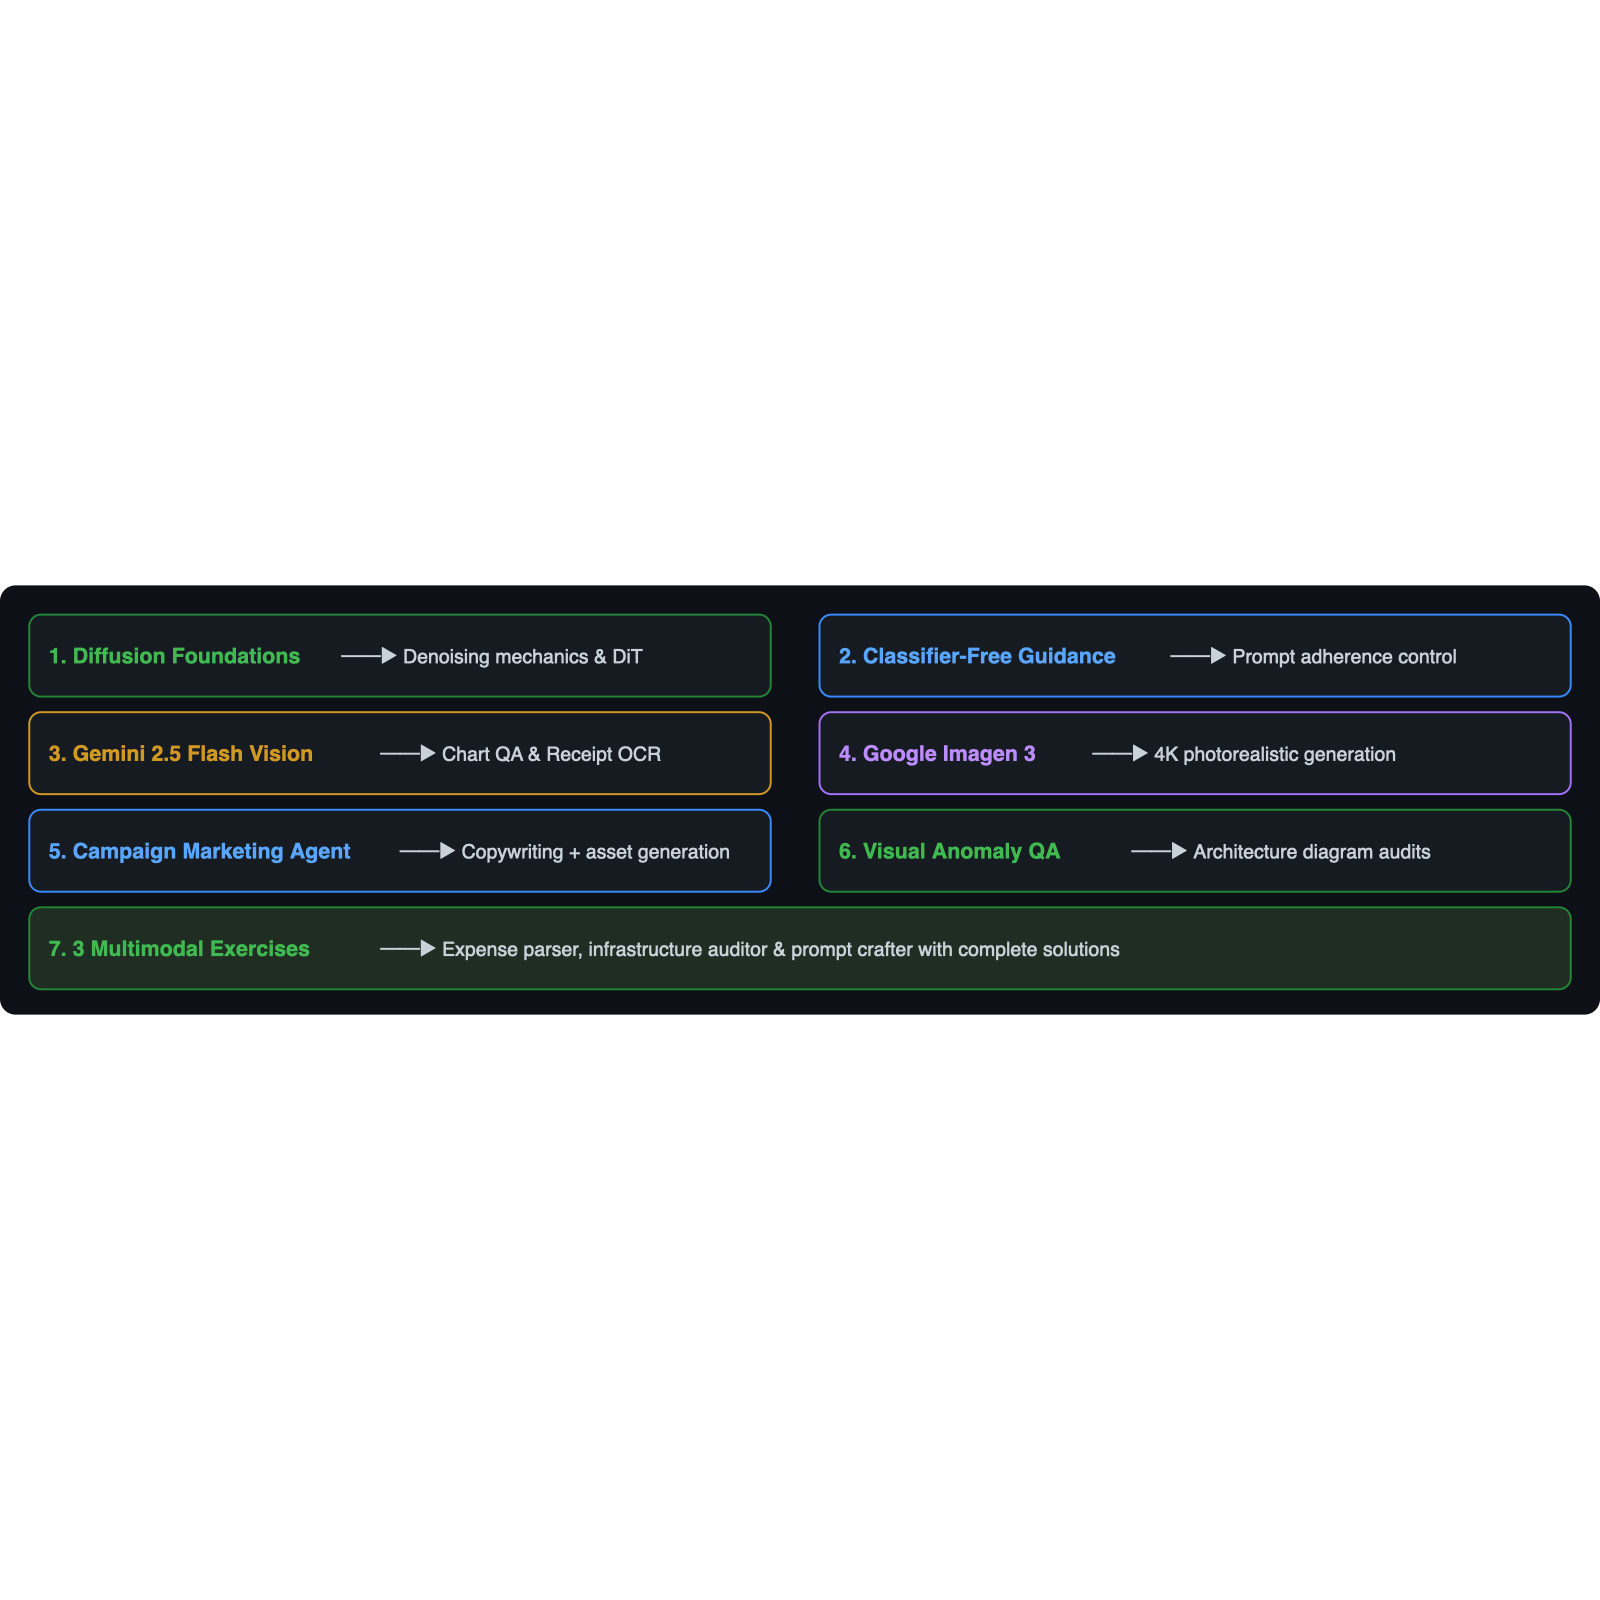
</p>

---

## 🗺️ What You Will Master in This Project:
<p align="center">
  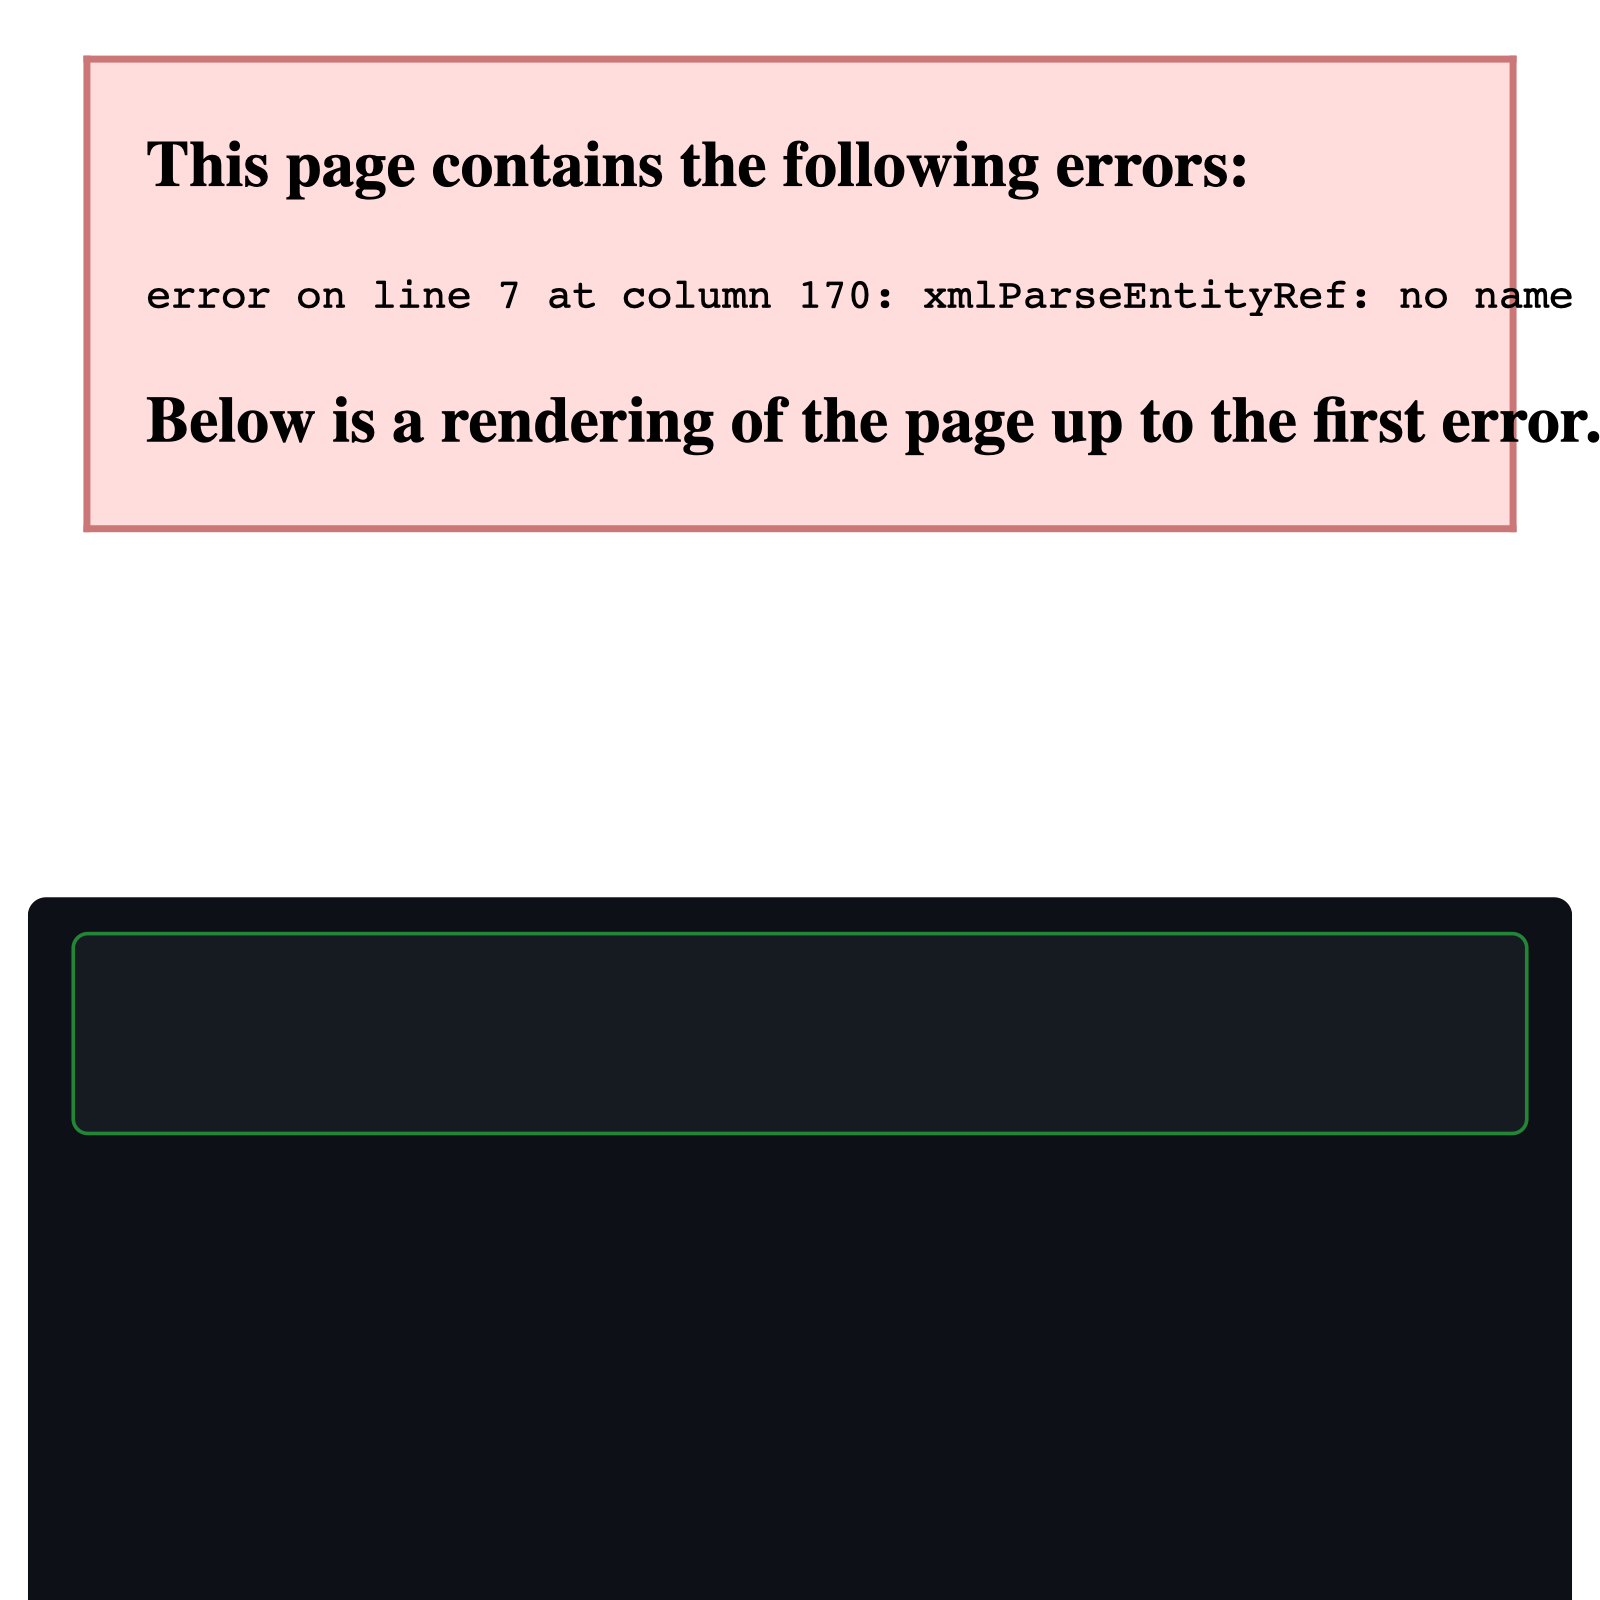
</p>


---
## Environment Setup & Client Initialization
We install the `google-genai` SDK, `pillow` for image processing, `matplotlib`, and `pydantic`.


In [ ]:
# Install required dependencies
!pip install -q google-genai pillow pydantic matplotlib rich


In [ ]:
import os
import getpass
from PIL import Image, ImageDraw, ImageFont
import io
import matplotlib.pyplot as plt
from google import genai
from google.genai import types

# Authenticate via API Key or Vertex AI
if "GEMINI_API_KEY" not in os.environ:
    api_key = getpass.getpass("Enter your Gemini API Key (or press enter for Vertex AI auth): ")
    if api_key:
        os.environ["GEMINI_API_KEY"] = api_key

if os.environ.get("GEMINI_API_KEY"):
    client = genai.Client()
    print("✅ Google GenAI Client initialized via API Key.")
else:
    PROJECT_ID = os.environ.get("GOOGLE_CLOUD_PROJECT", "your-project-id")
    LOCATION = os.environ.get("GOOGLE_CLOUD_LOCATION", "us-central1")
    client = genai.Client(vertexai=True, project=PROJECT_ID, location=LOCATION)
    print(f"✅ Google GenAI Client initialized via Vertex AI ({PROJECT_ID}).")


---
## 1. Generative Media Foundations: The Evolution of Image Generation

Before Diffusion models, generative AI used **GANs (Generative Adversarial Networks)** and **VAEs (Variational Autoencoders)**:

<p align="center">
  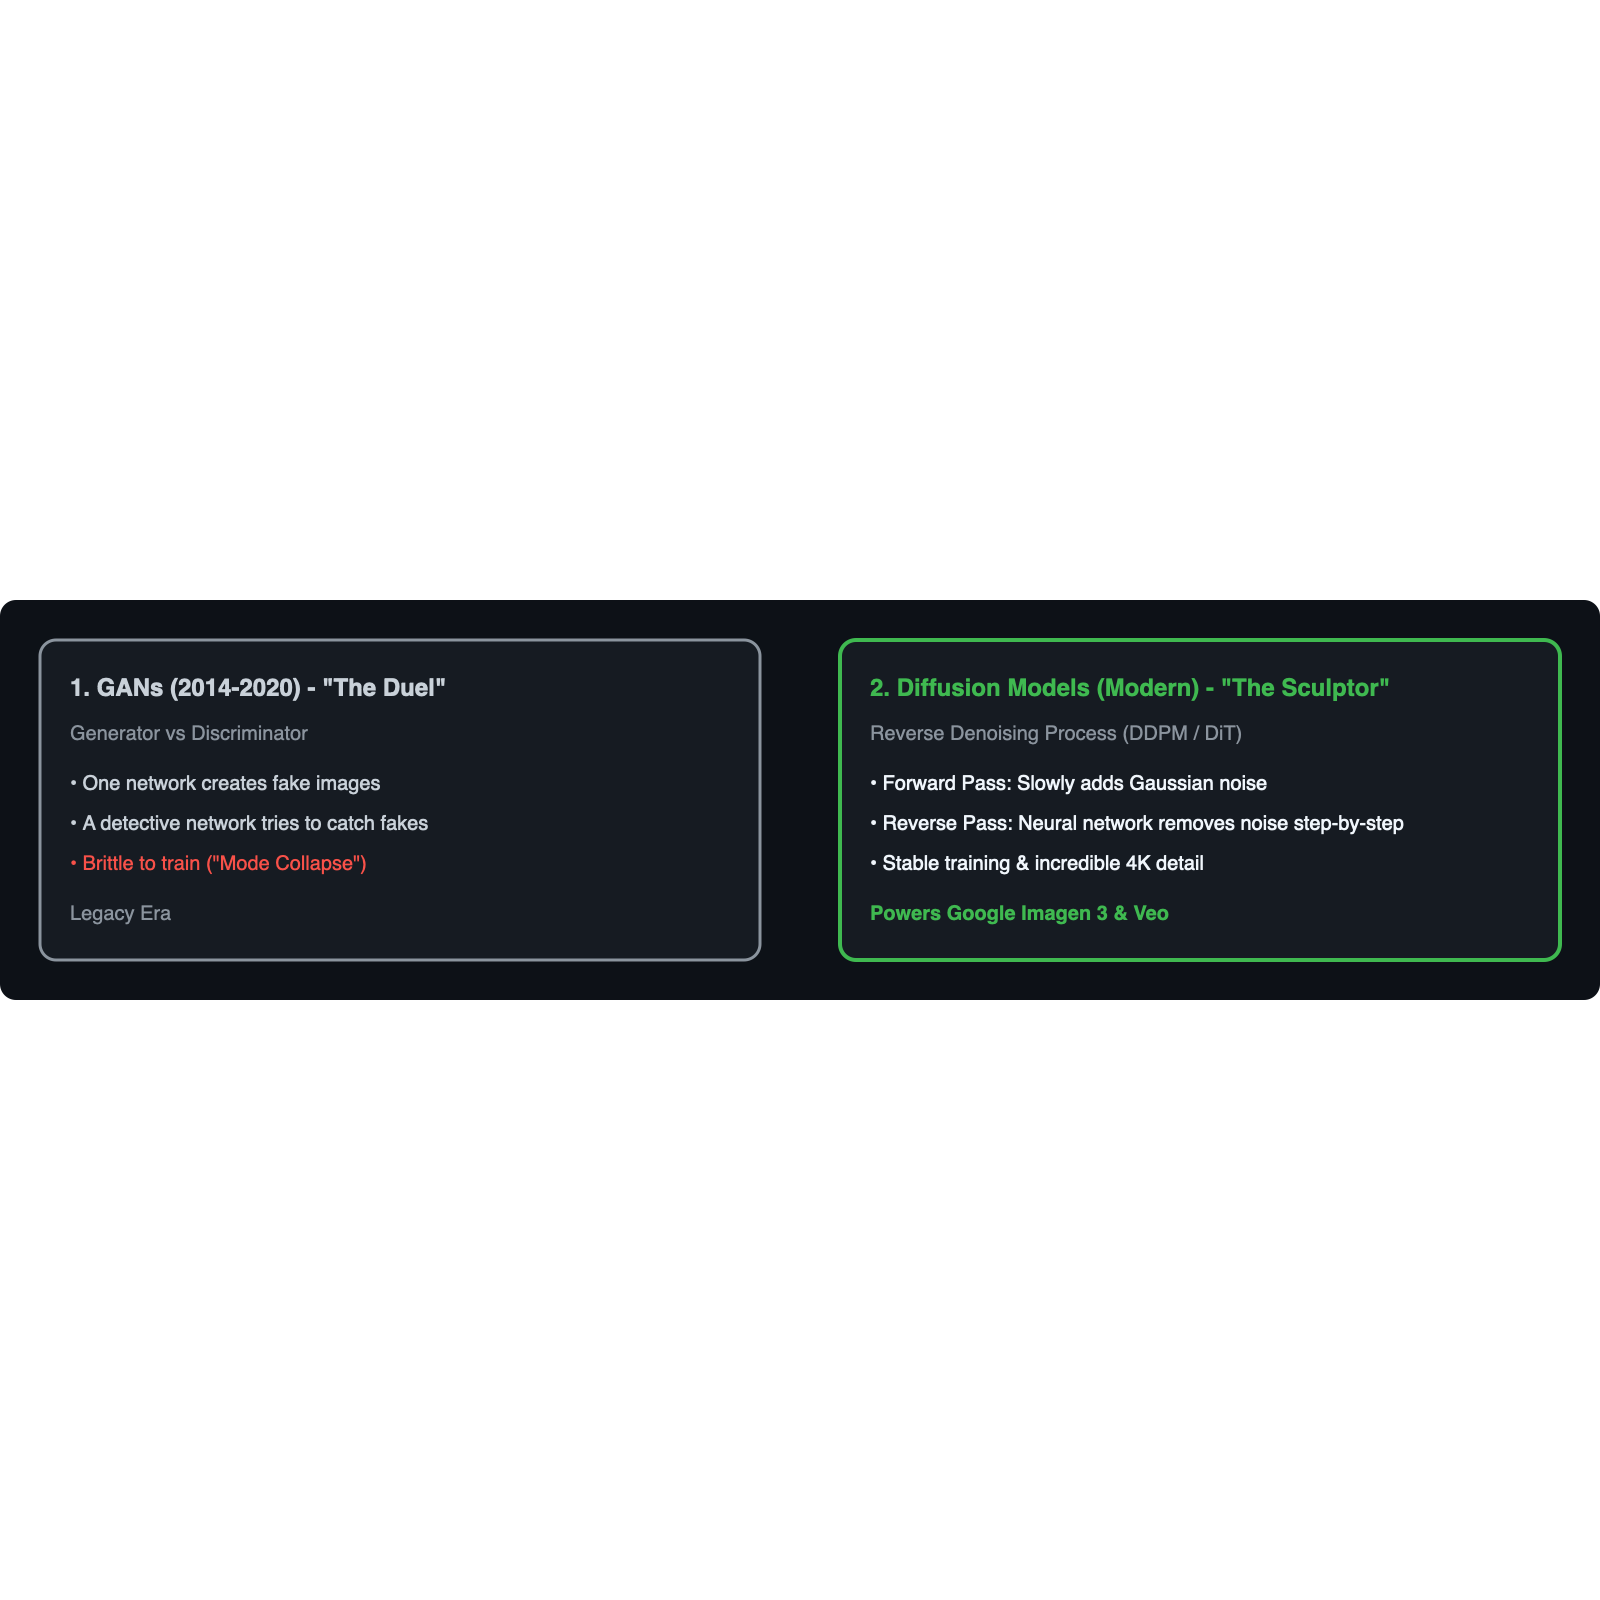
</p>


---
## 2. Text-to-Image (T2I) & Text-to-Video (T2V) Architectures

Why did image and video models suddenly get so good recently?

<p align="center">
  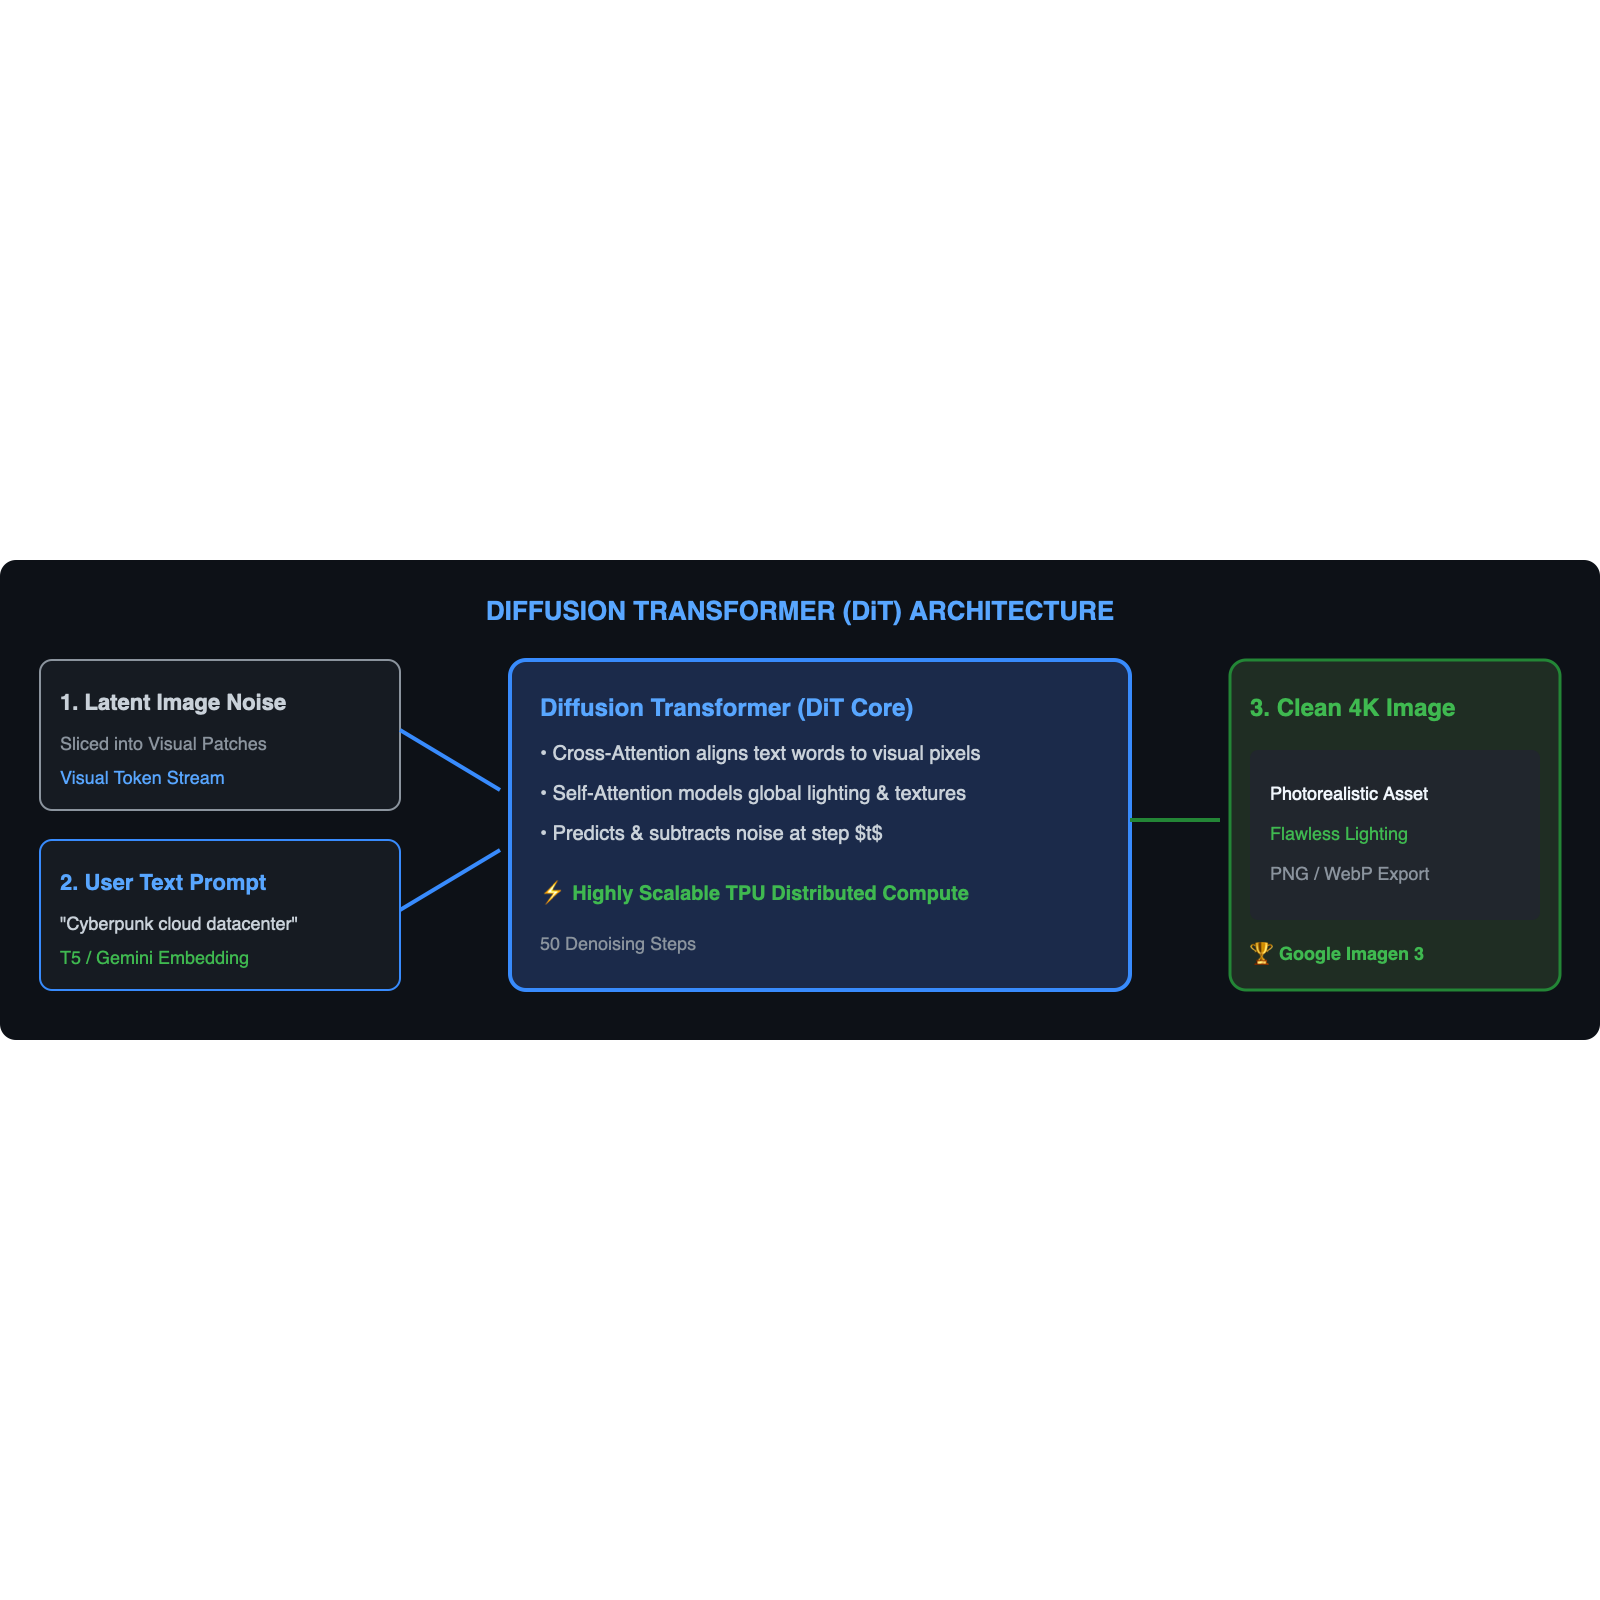
</p>


---
## 3. Multimodal Vision & Image Understanding with Gemini 2.5 Flash

Gemini 2.5 Flash natively ingests images, PDFs, diagrams, and video frames without requiring separate OCR or captioning models.

Let's generate a synthetic business chart and analyze it with Gemini:


In [ ]:
# Create a synthetic business metrics chart using matplotlib
fig, ax = plt.subplots(figsize=(7, 4))
quarters = ['Q1-25', 'Q2-25', 'Q3-25', 'Q4-25', 'Q1-26']
cloud_run_revenue = [12.4, 18.2, 24.5, 31.0, 42.8]
vertex_ai_revenue = [8.1, 15.6, 28.4, 45.2, 68.0]

ax.plot(quarters, cloud_run_revenue, marker='o', linewidth=2.5, label='Cloud Run ARR ($M)', color='#1a73e8')
ax.plot(quarters, vertex_ai_revenue, marker='s', linewidth=2.5, label='Vertex AI ARR ($M)', color='#ea4335')
ax.set_title("Enterprise Cloud Growth Trajectory (2025-2026)", fontsize=13, fontweight='bold')
ax.set_ylabel("Revenue ($ Millions USD)")
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()
plt.tight_layout()

# Save chart to in-memory bytes
img_buf = io.BytesIO()
plt.savefig(img_buf, format='PNG')
img_buf.seek(0)
pil_chart = Image.open(img_buf)
plt.show()

print("📊 Synthetic Enterprise Revenue Chart generated successfully.")


In [ ]:
# Pass PIL Image directly to Gemini 2.5 Flash for Multimodal Visual Analysis
prompt = """
Analyze the attached business chart:
1. Extract exact revenue figures for Vertex AI and Cloud Run in Q1-26.
2. Calculate the compound quarterly growth rate (CQGR) for Vertex AI from Q1-25 to Q1-26.
3. Provide strategic executive insights on which service is accelerating faster.
"""

response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=[pil_chart, prompt],
    config=types.GenerateContentConfig(temperature=0.1)
)

print("👁️ Multimodal Visual Analysis Output:")
print("="*60)
print(response.text)


---
## 4. Text-to-Image Generation with Google Imagen 3

Google **Imagen 3 (`imagen-3.0-generate-002`)** is Google's state-of-the-art diffusion image generation model, producing photorealistic imagery, typography rendering, and artistic compositions with high prompt fidelity.

Let's test generating an enterprise visual asset with Imagen 3:


In [ ]:
def generate_marketing_image(
    prompt: str,
    aspect_ratio: str = "16:9",
    number_of_images: int = 1
) -> Any:
    """Generates high-fidelity visual assets using Imagen 3."""
    print(f"🎨 Generating {number_of_images} image(s) with Imagen 3 (Aspect Ratio: {aspect_ratio})...")
    
    try:
        result = client.models.generate_images(
            model="imagen-3.0-generate-002",
            prompt=prompt,
            config=types.GenerateImagesConfig(
                number_of_images=number_of_images,
                aspect_ratio=aspect_ratio,
                person_generation="ALLOW_ADULT",
                output_mime_type="image/jpeg"
            )
        )
        return result.generated_images
    except Exception as e:
        print(f"⚠️ Imagen 3 API Call: {e}")
        print("💡 (Note: If running in test mode without Imagen 3 quota, ensure billing/quota is enabled on your project).")
        return None

# Test Image Generation Prompt
image_prompt = (
    "A sleek, futuristic glass enterprise cloud server room with glowing cyan and orange fiber optic conduits, "
    "ultra-detailed architectural photography, cinematic lighting, 8k resolution, photorealistic."
)

images = generate_marketing_image(image_prompt, aspect_ratio="16:9")
if images:
    for idx, generated_image in enumerate(images):
        image = Image.open(io.BytesIO(generated_image.image.image_bytes))
        plt.figure(figsize=(8, 4.5))
        plt.imshow(image)
        plt.axis('off')
        plt.title(f"Imagen 3 Asset #{idx+1}")
        plt.show()


---
## 5. End-to-End Implementation: The Autonomous Multimodal Campaign Agent

Let's build an integrated Multimodal Agent that:
1. Ingests raw product specifications and visual sketches/charts.
2. Formulates an omnichannel launch strategy (LinkedIn announcement, Technical Blog post, Press Release).
3. Automatically synthesizes detailed photorealistic image prompts with camera lighting and composition rules.
4. Triggers Imagen 3 to generate accompanying campaign graphics.


In [ ]:
from pydantic import BaseModel, Field
from typing import List

class ImagePromptSpec(BaseModel):
    asset_name: str
    target_channel: str = Field(description="e.g. 'Social Hero Image', 'Technical Architecture Diagram', 'Press Header'")
    detailed_imagen_prompt: str = Field(description="Photorealistic prompt with lighting, camera angle, and style descriptors")
    aspect_ratio: str = Field(description="'16:9', '1:1', or '9:16'")

class CampaignPlan(BaseModel):
    campaign_title: str
    target_audience: str
    executive_press_release: str
    linkedin_announcement: str
    visual_assets: List[ImagePromptSpec]

class MultimodalCampaignAgent:
    """Autonomous agent coordinating multimodal analysis, copywriting, and visual asset synthesis."""
    
    def __init__(self, client: genai.Client):
        self.client = client
        
    def create_campaign(self, product_spec: str, reference_image: Image.Image = None) -> CampaignPlan:
        print("🚀 [Phase 1: Analyzing Product Spec & Multimodal Assets...]")
        
        system_instruction = """
You are a Principal Creative Director & AI Product Marketing Strategist.
Generate an end-to-end launch campaign for the specified enterprise technology.
Create targeted copy and engineer precise Imagen 3 visual prompts.
"""
        user_content = [f"PRODUCT SPECIFICATION:\n{product_spec}"]
        if reference_image:
            user_content.append(reference_image)
            
        resp = self.client.models.generate_content(
            model="gemini-2.5-flash",
            contents=user_content,
            config=types.GenerateContentConfig(
                system_instruction=system_instruction,
                response_mime_type="application/json",
                response_schema=CampaignPlan,
                temperature=0.3
            )
        )
        return CampaignPlan.model_validate_json(resp.text)

# Test Campaign Agent
agent = MultimodalCampaignAgent(client)
product_spec = """
Product Name: Google Cloud Quantum-Secure Mesh (QSM)
Description: A next-generation zero-trust networking service utilizing Post-Quantum Cryptography (Kyber & Dilithium algorithms) to protect enterprise inter-region traffic against harvest-now-decrypt-later attacks.
Key Features: Sub-1ms encryption overhead, automated key rotation, native Cloud Run and GKE integration.
"""

campaign = agent.create_campaign(product_spec, reference_image=pil_chart)

print("
" + "="*80)
print(f"🎉 CAMPAIGN DOSSIER: {campaign.campaign_title}")
print("="*80)
print(f"🎯 Target Audience: {campaign.target_audience}
")
print(f"📱 LinkedIn Announcement:
{campaign.linkedin_announcement}
")
print("-" * 50)
print("🎨 Planned Visual Asset Prompts:")
for asset in campaign.visual_assets:
    print(f"• [{asset.target_channel}] ({asset.aspect_ratio}):")
    print(f"  Prompt: {asset.detailed_imagen_prompt}
")


---
## 6. Practical Hands-On Exercises (With Beginner Hints & Starter Code)

Test your multimodal engineering skills by completing these three enterprise visual tasks:

---

### 🎯 Exercise 5.1: Structured Invoice & Receipt Extractor
**The Business Scenario**: Finance teams process thousands of PDF and JPG invoices monthly. A Forward Deployment Applied AI engineer builds an automated vision extractor that parses line items, tax, and totals directly into Pydantic schemas!
- **Task**: Implement `extract_structured_receipt(image: Image.Image, client: genai.Client)` to extract vendor, date, line items, and total.
- **💡 Beginner Hint**: Define a Pydantic `Receipt` model and pass `response_schema=Receipt` in `types.GenerateContentConfig()`.

---

### 🎯 Exercise 5.2: Production Prompt Enhancer for Imagen 3
**The Business Scenario**: Non-technical marketers type weak prompts like *"cool cloud server"*. Your prompt enhancer expands this into studio-grade photography specs (*"cinematic volumetric lighting, 85mm lens, depth of field, sleek server racks"*).
- **Task**: Implement `enhance_diffusion_prompt(raw_idea: str, client: genai.Client) -> str`.
- **💡 Beginner Hint**: Ask Gemini to act as a Hollywood Director and add camera angles, lighting styles, and realistic textures.

---

### 🎯 Exercise 5.3: Video Storyboard Scene Generator
**The Business Scenario**: Creative agencies turn narrative scripts into 4-shot video storyboards with exact camera movement instructions (drone pan, close-up, dolly zoom).
- **Task**: Create `generate_video_storyboard(script_outline: str, client: genai.Client)` to output 4 sequential scenes with camera directions.
- **💡 Beginner Hint**: Use a Pydantic list of `Scene` objects with `scene_number`, `duration_sec`, `camera_movement`, and `visual_prompt`.


---
## 7. Step-by-Step Solutions & Architectural Explanations


In [ ]:
# ============================================================================
# SOLUTION 5.1: Structured Multimodal Receipt Extractor
# ============================================================================
class LineItem(BaseModel):
    description: str
    quantity: int
    unit_price: float
    total_price: float

class InvoiceData(BaseModel):
    vendor_name: str
    invoice_date: str
    currency: str
    line_items: List[LineItem]
    tax_amount: float
    grand_total: float

def extract_structured_receipt(image: Image.Image, client: genai.Client) -> InvoiceData:
    prompt = "Extract all itemized transaction details from this invoice image into strict structured JSON."
    resp = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=[image, prompt],
        config=types.GenerateContentConfig(
            response_mime_type="application/json",
            response_schema=InvoiceData,
            temperature=0.0
        )
    )
    return InvoiceData.model_validate_json(resp.text)

print("🧾 Solution 5.1 function defined with Pydantic schema validation.")


In [ ]:
# ============================================================================
# SOLUTION 5.2: Automated Diffusion Prompt Enhancer
# ============================================================================
def enhance_diffusion_prompt(raw_idea: str, client: genai.Client) -> str:
    """Expands raw concept into photorealistic Imagen 3 prompt specification."""
    prompt = f"""
You are an expert Prompt Engineer for Google Imagen 3 diffusion models.
Expand this raw concept into a rich, photorealistic, high-detail visual prompt:
Concept: "{raw_idea}"

Include:
- Exact subject details and physical materials
- Lighting (e.g. volumetric god rays, cinematic softbox, rim light)
- Camera & Lens (e.g. Hasselblad H6D-100c, 85mm f/1.4 lens, shallow depth of field)
- Atmosphere & Color grading (e.g. muted cybernetic tones, 8k, photorealistic)

Output ONLY the enhanced prompt string.
"""
    resp = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=prompt,
        config=types.GenerateContentConfig(temperature=0.4)
    )
    return resp.text.strip()

enhanced = enhance_diffusion_prompt("An Applied AI engineer working late in a glass server room overlooking Tokyo skyline", client)
print("✨ Enhanced Imagen 3 Prompt:")
print(enhanced)


In [ ]:
# ============================================================================
# SOLUTION 5.3: Video Storyboard Scene Generator
# ============================================================================
class StoryboardScene(BaseModel):
    scene_number: int
    duration_seconds: int
    visual_description: str
    camera_movement: str = Field(description="e.g. 'Slow dolly-in', 'Orbit tracking shot', 'Aerial crane descent'")
    voiceover_audio_script: str

class VideoStoryboard(BaseModel):
    video_title: str
    total_duration_seconds: int
    scenes: List[StoryboardScene]

def generate_video_storyboard(script_outline: str, client: genai.Client) -> VideoStoryboard:
    prompt = f"""
Deconstruct the following product narrative into a 4-scene video storyboard:
Outline: "{script_outline}"
"""
    resp = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=prompt,
        config=types.GenerateContentConfig(
            response_mime_type="application/json",
            response_schema=VideoStoryboard,
            temperature=0.2
        )
    )
    return VideoStoryboard.model_validate_json(resp.text)

storyboard = generate_video_storyboard("Announcing Google Cloud Next-Gen TPU v6 AI Superclusters", client)
print(f"🎬 Video Storyboard: {storyboard.video_title} ({storyboard.total_duration_seconds}s)")
for sc in storyboard.scenes:
    print(f"• Scene {sc.scene_number} ({sc.duration_seconds}s) | Camera: {sc.camera_movement}")
    print(f"  Visual: {sc.visual_description}")
    print(f"  VO: "{sc.voiceover_audio_script}"\n")


---
## Summary & Key Takeaways
1. **Diffusion Mechanics**: Forward noise scheduling and reverse neural score estimation power modern image and video synthesis.
2. **Diffusion Transformers (DiT)**: Scalable Transformer backbones replace traditional convolutional U-Nets, unlocking higher FID scores and consistent video spatio-temporal coherence.
3. **Multimodal Agent Orchestration**: Combining Gemini's visual comprehension with Imagen 3's high-fidelity asset generation enables fully automated creative and technical marketing pipelines.
4. **Next Step**: In **Project 6 (Capstone)**, we integrate all 5 course modules into a unified enterprise platform: **OmniOps - Autonomous Enterprise Intelligence Platform deployed to Google Cloud Run**!
